# Example-1 (Non LLM)

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from dotenv import load_dotenv

load_dotenv()
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [2]:
class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str


In [3]:
# Function for nodes
def show_equation(state: QuadState):

    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'

    return {'equation':equation}

def calculate_discriminant(state: QuadState):

    discriminant = state["b"]**2 - (4*state["a"]*state["c"])

    return {'discriminant': discriminant}

def real_roots(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state: QuadState):

    result = f'No real roots'

    return {'result': result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [4]:
# Graph design
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)


graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()


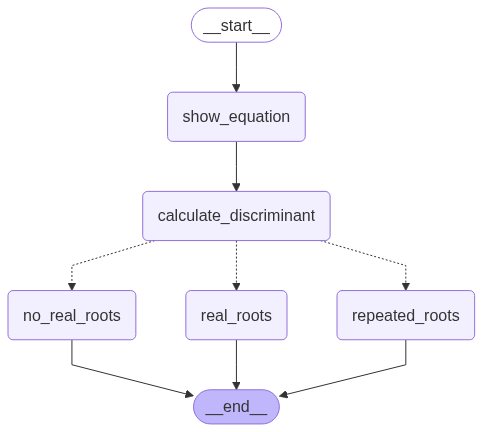

In [5]:
workflow


In [6]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)



{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x24x2',
 'discriminant': 0,
 'result': 'Only repeating root is -1.0'}

# Example-2 (LLM)

In [7]:
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
import operator

load_dotenv()
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [10]:
# Structured Output
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')



In [8]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [11]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)


In [12]:
# testing the structure
prompt = 'What is the sentiment of the following review - The software too good'
structured_model.invoke(prompt).sentiment


'positive'

In [13]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str


In [14]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [15]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

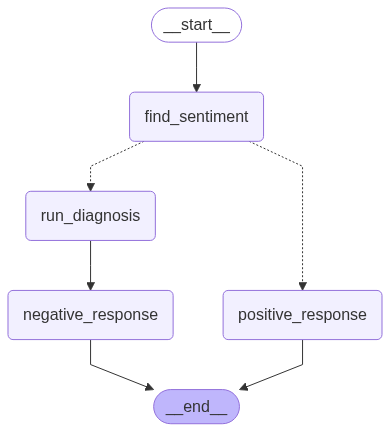

In [16]:
workflow

In [17]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)



{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "I'm so sorry to hear you're experiencing this bug and that it's causing you frustration. I understand how disruptive and stressful it can be when something isn't working as expected, especially when you're on a tight deadline.\n\nPlease know that we're taking this very seriously and are working diligently to get this resolved for you as quickly as possible.\n\nTo help us pinpoint the exact issue and expedite a fix, could you please provide us with a little more detail? Specifically, if you could share:\n\n*   **What exactly is happening?** (e.g., error messages, unexpected behavior, features not loading)\n*   **When did this bug 

# Testing

In [156]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

class testState(TypedDict):
    val : int
    sqr : float
    rootsqr : float
    cube : float
    inputs : str
    response : float

def inputval(state : testState) -> testState:
    aa =  state['val']
    if aa > 0 and aa <= 5:
        inputs = 'squareval'
    elif aa > 5 and aa <= 10:
        inputs = 'rootval'
    else:
        inputs = 'cubeval'
    
    return {'inputs' : inputs}


def squareval(state : testState):
    sqr = state['val']**2
    print(state)
    return {'sqr': sqr}

def rootval(state : testState):
    rootsqr = state['val']**0.5
    print(state)
    return {'rootsqr': rootsqr}    

def cubeval(state : testState): 
    cube = state['val']**3
    print(state)
    return {'cube': cube}  


def check_Condition(state : testState) -> Literal['squareval','rootval','cubeval']:
    aa =  state['inputs']
    if state['inputs'] == 'squareval':
        return 'squareval'
    elif state['inputs'] == 'rootval':
        return 'rootval'
    else:
        return 'cubeval'

def responseval(state : testState): 
    if state['inputs'] == 'squareval':
        response = state['sqr']
    elif state['inputs'] == 'rootval':
        response = state['rootsqr']
    else:
        response = state['cube']
    print(state)    
    return {'response': response}  
    

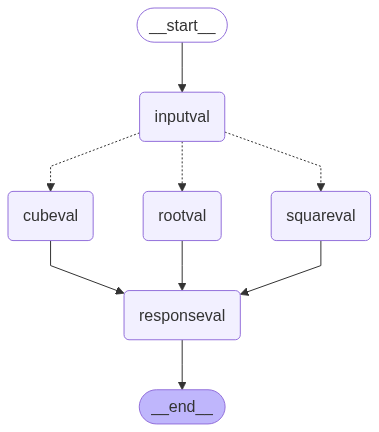

In [157]:
graph = StateGraph(testState)

graph.add_node('inputval',inputval)
#graph.add_node('check_Condition',check_Condition)
graph.add_node('squareval',squareval)
graph.add_node('rootval',rootval)
graph.add_node('cubeval',cubeval)
graph.add_node('responseval',responseval)

graph.add_edge(START,'inputval')
# graph.add_edge('inputval','check_Condition')
# graph.add_edge('check_Condition',END)

graph.add_edge('inputval',END)
graph.add_conditional_edges('inputval',check_Condition)
graph.add_edge('squareval','responseval')
graph.add_edge('rootval','responseval')
graph.add_edge('cubeval','responseval')
graph.add_edge('responseval',END)

workflow = graph.compile()
workflow

In [158]:
initial = {'val': 5}
result = workflow.invoke(initial)

{'val': 5, 'inputs': 'squareval'}
{'val': 5, 'sqr': 25, 'inputs': 'squareval'}


In [155]:
result, result['response']

({'val': 5, 'sqr': 25, 'inputs': 'squareval', 'response': 25}, 25)